Welcome, solar physicists!  

> **TA / instructor SOLUTION version.** This copy has all the `YOUR CODE HERE` blanks filled in. Distribute the *student version* to pupils.

In this notebook, you'll use Python, basic mathematics, and image analysis to analyse images of our Sun, including a special type of image called a "Dopplergram" that shows motion towards/away from us.  This will allow us to investigate the Sun's remarkable rotation.  

Follow the instructions in each section and fill in code where needed.


In [1]:
# --- Section 1: Setting the Stage ---

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image # Pillow library for image handling
import scipy.ndimage as ndi # For morphological operations (e.g., removing small features)
from skimage import measure # For contour finding (useful for sunspots)
from scipy.optimize import curve_fit # For fitting a curve to data

print("Libraries loaded successfully!")



Libraries loaded successfully!


Visible light image 'sun_visible.png' loaded successfully!
Dopplergram image 'sun_dopplergram.png' loaded successfully!
Image dimensions (both): 4096 x 4096 pixels


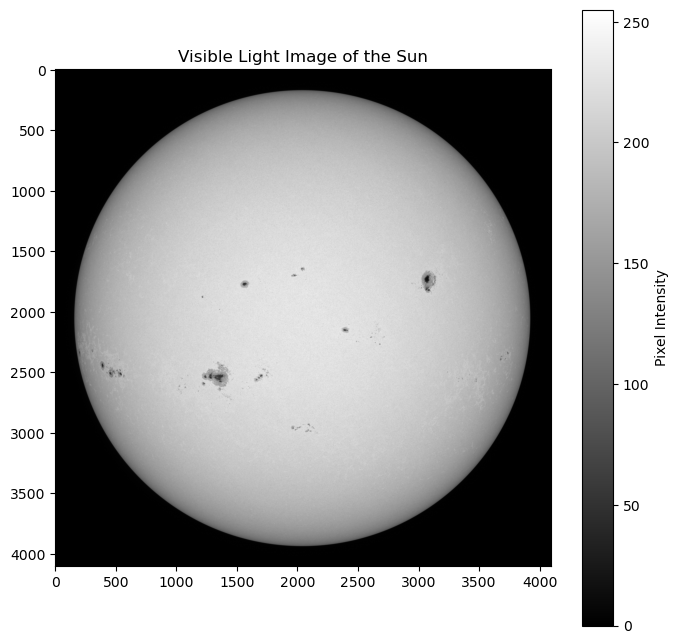

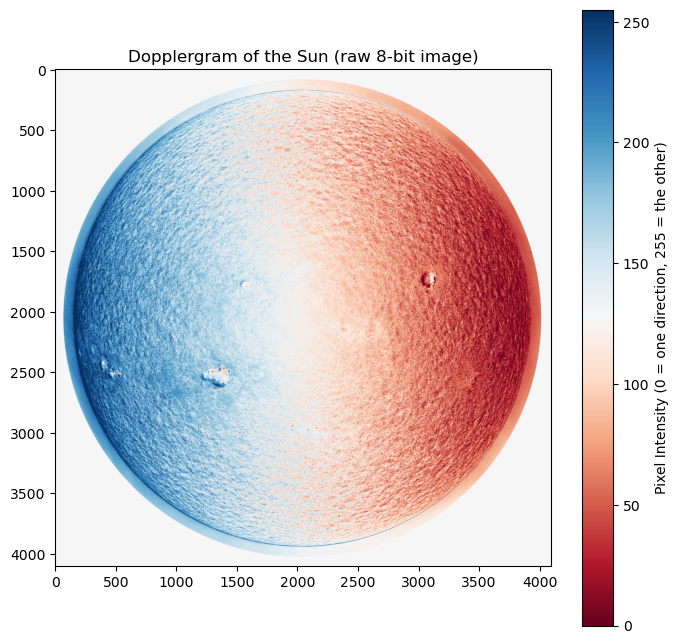

In [3]:
# Task 1.1: Load the Solar Images
# We need two images: a visible light image and a Dopplergram.
# Make sure 'sun_visible.png' and 'sun_dopplergram.png' are in the same directory!

visible_image_path = 'sun_visible.png'
doppler_image_path = 'sun_dopplergram.png'

try:
    # Load visible light image (often grayscale or color)
    # We'll convert it to grayscale for simpler analysis later
    raw_visible_image = Image.open(visible_image_path).convert('L') # Convert to grayscale
    visible_data = np.array(raw_visible_image)

    # Load Dopplergram image (should be grayscale, where intensity = velocity)
    raw_doppler_image = Image.open(doppler_image_path).convert('L') # Convert to grayscale
    doppler_data = np.array(raw_doppler_image)

    print(f"Visible light image '{visible_image_path}' loaded successfully!")
    print(f"Dopplergram image '{doppler_image_path}' loaded successfully!")
    print(f"Image dimensions (both): {visible_data.shape[1]} x {visible_data.shape[0]} pixels")


    ################
    # SOLUTION: use imshow to display visible_data, using a grayscale colourmap:
    plt.figure(figsize=(8, 8))
    plt.imshow(visible_data, cmap='gray')
    # give your plot a title and put in a colorbar:
    plt.title("Visible Light Image of the Sun")
    plt.colorbar(label='Pixel Intensity')
    plt.show()


    # Dopplergrams often show blue for approaching (blue-shifted) and red for receding (red-shifted).
    # Since our PNG is grayscale, we can use a diverging colourmap like 'RdBu' to visualize this.
    # We need to normalize the data to a specific range for the colormap.
    # Assuming 127 is zero velocity, 0 is max blue, 255 is max red.

    ################
    # SOLUTION: use imshow to display doppler_data using the RdBu colormap
    # Use the vmin=0,vmax=255 keywords, and give your plot a meaningful title
    # Include a colourbar
    plt.figure(figsize=(8, 8))
    plt.imshow(doppler_data, cmap='RdBu', vmin=0, vmax=255)
    plt.title("Dopplergram of the Sun (raw 8-bit image)")
    plt.colorbar(label='Pixel Intensity (0 = one direction, 255 = the other)')
    plt.show()


except FileNotFoundError:
    print(f"Error: One or both image files were not found.")
    print(f"Please ensure '{visible_image_path}' and '{doppler_image_path}' are in the same folder.")
    visible_data = None
    doppler_data = None
    
# Discussion Points:
# - What features do you see in the visible light image?
# - What do you think the colors/shades in the Dopplergram indicate? 
#   Look for a pattern that suggests rotation!

# Why do you think the intensity is strongest near the "limbs" of the Sun? 
# What effects other than rotation might affect the velocity towards/away from us?


--- Section 2: Basic Image Properties and Statistics (Visible Light) ---
Minimum pixel intensity: 0
Maximum pixel intensity: 255
Mean pixel intensity:    124.12


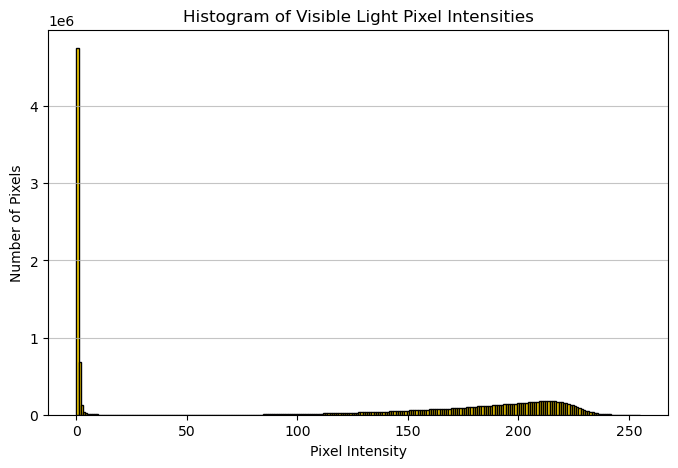

In [4]:

#Now let's do some basic statistics on the image, including a histogram of intensity values

if visible_data is not None:
    print("\n--- Section 2: Basic Image Properties and Statistics (Visible Light) ---")

    # Task 2.1-2.2: Find the Minimum,  Maximum, and Mean Pixel Intensities in Visible Light Image
    
    ################
    # SOLUTION: find the minimum, maximum, and mean values of the visible_data image, and print out the results
    min_intensity = visible_data.min()
    max_intensity = visible_data.max()
    mean_intensity = visible_data.mean()
    print(f"Minimum pixel intensity: {min_intensity}")
    print(f"Maximum pixel intensity: {max_intensity}")
    print(f"Mean pixel intensity:    {mean_intensity:.2f}")

    #do the results make sense to you?
    # The minimum is 0 (the black background outside the solar disk); the maximum is near 255
    # (the bright photosphere); the mean sits well below mid-grey because so much of the frame
    # is black background.

    # Task 2.3: Display a Histogram of Pixel Intensities
    plt.figure(figsize=(8, 5))
    plt.hist(visible_data.ravel(), bins=256, range=(0, 255), color='gold', edgecolor='black')
    plt.title("Histogram of Visible Light Pixel Intensities")
    plt.xlabel("Pixel Intensity")
    plt.ylabel("Number of Pixels")
    plt.grid(axis='y', alpha=0.75)
    plt.show()

    # Discussion Point: What does the histogram tell you about the distribution of brightness?


--- Section 3: Feature Extraction - Finding Sunspots (Visible Light) ---
Sunspots are cooler, darker regions on the Sun's surface. Can we find them automatically?
Threshold 30: 4 raw candidate regions
Threshold 50: 20 raw candidate regions
Threshold 70: 19 raw candidate regions
Threshold 90: 55 raw candidate regions
Threshold 110: 176 raw candidate regions


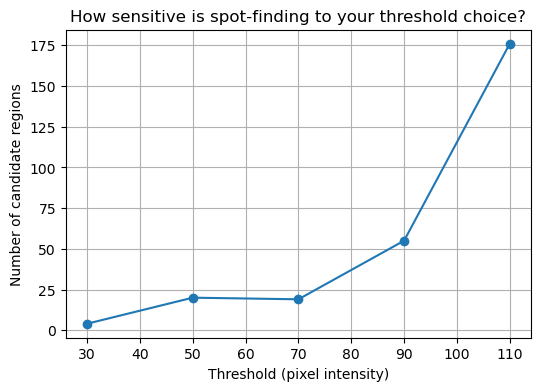


Found 20 raw regions at threshold 50.
Kept 11 plausible sunspots after filtering.


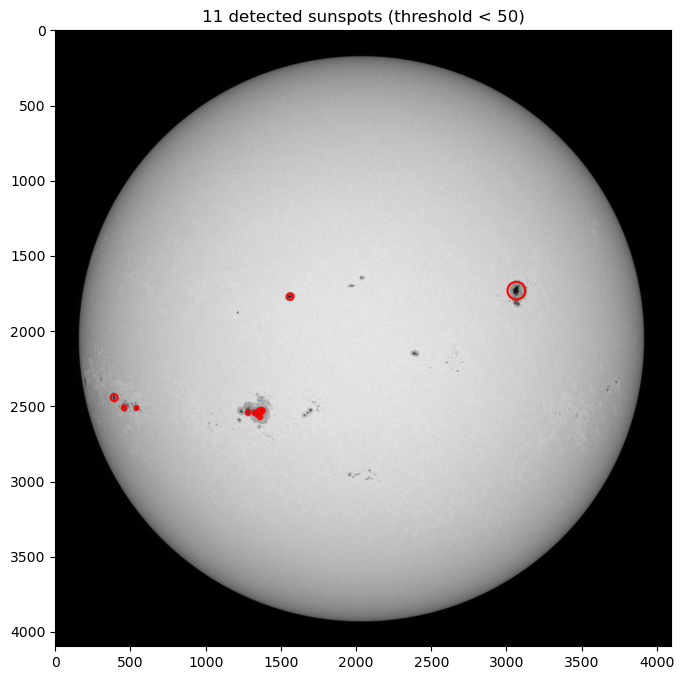

Total sunspot area: 2260 pixels (203.3 millionths of the visible hemisphere)


In [5]:
# --- Section 3: Feature Extraction - Finding Sunspots (Visible Light) --- [SOLUTION VERSION]

if visible_data is not None:
    print("\n--- Section 3: Feature Extraction - Finding Sunspots (Visible Light) ---")
    print("Sunspots are cooler, darker regions on the Sun's surface. Can we find them automatically?")

    # Task 3.1: Mask out everything that isn't actually part of the Sun's disk.
    # (Otherwise our threshold will also "detect" the black background outside the disk!)
    solar_disk_mask = visible_data > 10

    # Task 3.2: Investigate how the choice of threshold affects the number of spots found.
    # Try a handful of threshold values and count how many candidate regions each finds.
    test_thresholds = [30, 50, 70, 90, 110]
    counts = []
    for t in test_thresholds:
        trial_mask = (visible_data < t) & solar_disk_mask
        _, n = measure.label(trial_mask, return_num=True)
        counts.append(n)
        print(f"Threshold {t}: {n} raw candidate regions")

    plt.figure(figsize=(6,4))
    plt.plot(test_thresholds, counts, 'o-')
    plt.xlabel("Threshold (pixel intensity)")
    plt.ylabel("Number of candidate regions")
    plt.title("How sensitive is spot-finding to your threshold choice?")
    plt.grid(True)
    plt.show()

    # Discussion: Why does the number of "regions" change so much with threshold?
    # Is a bigger number of regions always better? What's going wrong at very low/high thresholds?
    #
    # SAMPLE ANSWER: At low thresholds (e.g. 30) we're stricter, so we only catch the darkest
    # cores of the biggest spots -> fewer regions. As the threshold rises we catch more real
    # penumbral/fainter structure, but by ~90-110 we start picking up granulation and limb
    # darkening noise near the edge of the disk, so the count balloons without corresponding
    # to real sunspots anymore. More regions isn't "better" -- past some point it means we're
    # detecting noise, not physics.

    # Based on the plot above, a threshold in the 50-70 range looks like a good compromise:
    # low enough to reject granulation noise, high enough to catch full spot penumbrae.
    sunspot_threshold = 50

    # Task 3.3: Find and measure the actual sunspots at your chosen threshold
    dark_pixels_mask = (visible_data < sunspot_threshold) & solar_disk_mask
    labeled_spots, num_features = measure.label(dark_pixels_mask, return_num=True)
    all_spots = measure.regionprops(labeled_spots)
    print(f"\nFound {num_features} raw regions at threshold {sunspot_threshold}.")

    # Filter out regions that are too small (noise) or implausibly large (background leaks)
    min_spot_size = 50
    max_spot_size = 10000
    good_spots = [spot for spot in all_spots if min_spot_size < spot.area < max_spot_size]
    print(f"Kept {len(good_spots)} plausible sunspots after filtering.")

    # Task 3.4: Mark the detected spots clearly (circles, since the spots are tiny relative to the image!)
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(visible_data, cmap='gray')
    for spot in good_spots:
        y, x = spot.centroid
        r = np.sqrt(spot.area / np.pi) * 3   # exaggerated for visibility
        circ = plt.Circle((x, y), r, color='red', fill=False, linewidth=1.5)
        ax.add_patch(circ)
    ax.set_title(f"{len(good_spots)} detected sunspots (threshold < {sunspot_threshold})")
    plt.show()

    # Task 3.5: Express the total sunspot area in a unit real astronomers use:
    # "millionths of solar hemisphere" (msh). A big active region is typically 500-3000 msh.
    disk_area_pixels = np.sum(solar_disk_mask)
    total_sunspot_area_pixels = sum(spot.area for spot in good_spots)
    msh = total_sunspot_area_pixels / disk_area_pixels * 1e6
    print(f"Total sunspot area: {total_sunspot_area_pixels:.0f} pixels ({msh:.1f} millionths of the visible hemisphere)")

    # SAMPLE RESULT (with sunspot_threshold=50): 11 spots kept, ~2260 pixels total, ~203 msh.
    # For context, that's a moderately active Sun - well below a huge active region (1000+ msh)
    # but clearly more than a spotless/quiet-Sun day (~0 msh).

    # Discussion Points:
    # - Compare your msh value to real published sunspot-area records (e.g. NOAA/SIDC) - is
    #   today's Sun quiet or active?
    # - Try counting spots by eye first, then compare to the algorithm - did it miss anything?
    #   Find anything you wouldn't have counted?
    # - How does changing sunspot_threshold change your msh estimate? Which threshold do
    #   you trust, and why?

Calibrated Dopplergram 'sun_dopplergram_calibrated.npz' loaded successfully!

--- Section 4: Advanced Optional: Solar Differential Rotation from Dopplergram ---
The Sun doesn't rotate like a solid body: some latitudes rotate faster than others.
This is called 'differential rotation'. We can see evidence of this in the Dopplergram.
Sun centre: (2038, 2053), Radius: 1879 pixels.
Full-disk velocity range (includes noisy limb pixels): -9671 to 11831 m/s
Trusted range (inside 95% of the radius): -2344 to 6506 m/s


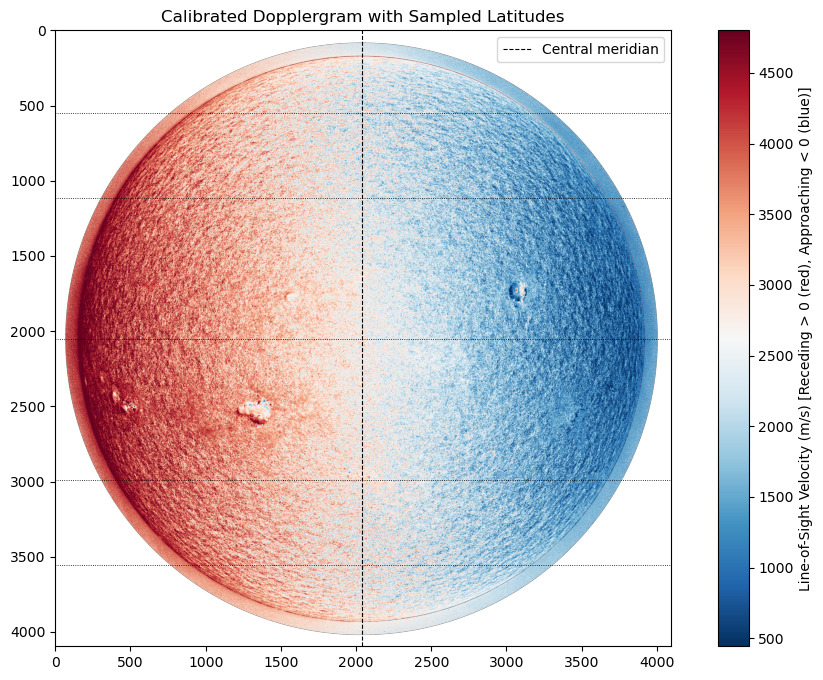

In [6]:
# --- Section 4: more advanced work: Solar Differential Rotation from Dopplergram ---

# Load the *calibrated* Dopplergram. Unlike the 8-bit PNG we displayed in Section 1,
# this file holds the REAL line-of-sight velocities in metres per second, derived from
# SDO/HMI data for 12 August 2024. Off-disk pixels are stored as NaN ("not a number").
try:
    calibrated = np.load('sun_dopplergram_calibrated.npz')
    doppler_velocity = calibrated['velocity']          # real line-of-sight velocity, m/s
    center_x = float(calibrated['center_x'])
    center_y = float(calibrated['center_y'])
    sun_radius = float(calibrated['sun_radius'])
    img_height, img_width = doppler_velocity.shape
    print("Calibrated Dopplergram 'sun_dopplergram_calibrated.npz' loaded successfully!")
except FileNotFoundError:
    print("Error: 'sun_dopplergram_calibrated.npz' not found.")
    print("Make sure it's in the same folder as this notebook.")
    doppler_velocity = None

if doppler_velocity is not None:
    print("\n--- Section 4: Advanced Optional: Solar Differential Rotation from Dopplergram ---")
    print("The Sun doesn't rotate like a solid body: some latitudes rotate faster than others.")
    print("This is called 'differential rotation'. We can see evidence of this in the Dopplergram.")

    # In a Dopplergram, pixels with POSITIVE velocity are moving away from us (red-shifted),
    # and NEGATIVE velocity pixels are moving towards us (blue-shifted).
    # NOTE: the whole disk sits at a large positive offset (~2600 m/s) -- and that's real!
    # It comes from the Sun's gravitational redshift plus the SDO spacecraft's own motion
    # along our line of sight. Rotation shows up as the left-right *gradient* on top of it.
    print(f"Sun centre: ({center_x:.0f}, {center_y:.0f}), Radius: {sun_radius:.0f} pixels.")

    # Doppler velocities become unreliable very close to the limb (the edge of the disk),
    # because the spectral line gets distorted by foreshortening there. So for the analysis
    # below we only TRUST pixels inside this fraction of the solar radius.
    TRUST_RADIUS = 0.95

    # Work out how far each pixel is from the disk centre, as a fraction of the radius,
    # then keep the pixels we trust (inside TRUST_RADIUS and not NaN / off-disk).
    ys_grid, xs_grid = np.mgrid[0:img_height, 0:img_width]
    r_frac = np.sqrt((xs_grid - center_x)**2 + (ys_grid - center_y)**2) / sun_radius
    trusted = (r_frac < TRUST_RADIUS) & ~np.isnan(doppler_velocity)

    # Notice how wide the raw range looks, and how much it shrinks once we drop the
    # unreliable limb pixels -- that's why the masking matters.
    print(f"Full-disk velocity range (includes noisy limb pixels): "
          f"{np.nanmin(doppler_velocity):.0f} to {np.nanmax(doppler_velocity):.0f} m/s")
    print(f"Trusted range (inside {TRUST_RADIUS:.0%} of the radius): "
          f"{np.min(doppler_velocity[trusted]):.0f} to {np.max(doppler_velocity[trusted]):.0f} m/s")

    # Task 4.1: Extract Velocities Across Different Latitudes
    # We select a few horizontal slices (rows) at different 'latitudes' on the Sun's disk.
    # Row 0 is the top, img_height-1 is the bottom, and center_y is the equator.
    lat_rows_pixels = [
        int(center_y),                     # Equator
        int(center_y - 0.5 * sun_radius),  # Mid-latitude North
        int(center_y + 0.5 * sun_radius),  # Mid-latitude South
        int(center_y - 0.8 * sun_radius),  # Near-pole North (kept clear of the unreliable limb)
        int(center_y + 0.8 * sun_radius)   # Near-pole South (kept clear of the unreliable limb)
    ]
    # Filter out rows outside image bounds
    lat_rows_pixels = [r for r in lat_rows_pixels if 0 <= r < img_height]

    # Pick a robust colour range: the 1st/99th percentile of the TRUSTED on-disk pixels
    # (computed above), so a handful of extreme limb pixels can't wash out the colours.
    vmin_disp, vmax_disp = np.nanpercentile(doppler_velocity[trusted], [1, 99])

    plt.figure(figsize=(12, 8))
    # 'RdBu_r' puts red at high (receding) values and blue at low (approaching) values,
    # matching the usual "red-shift / blue-shift" convention.
    plt.imshow(doppler_velocity, cmap='RdBu_r', vmin=vmin_disp, vmax=vmax_disp)
    plt.title("Calibrated Dopplergram with Sampled Latitudes")
    plt.colorbar(label='Line-of-Sight Velocity (m/s) [Receding > 0 (red), Approaching < 0 (blue)]')
    plt.axvline(x=center_x, color='black', linestyle='--', linewidth=0.8, label='Central meridian')
    for row_idx in lat_rows_pixels:
        plt.axhline(y=row_idx, color='black', linestyle=':', linewidth=0.6)
    plt.legend()

    # Store profiles for plotting
    velocity_profiles = {}

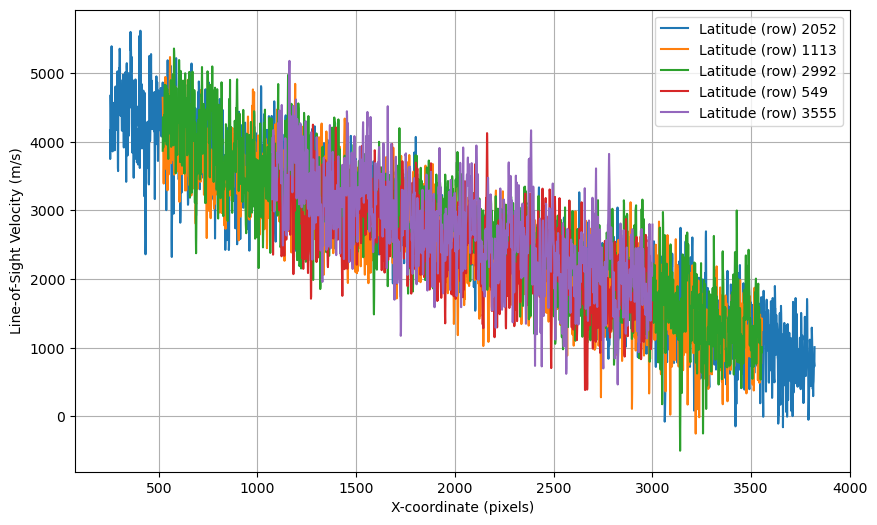

In [7]:
fig, ax = plt.subplots(figsize=(10, 6)) # if you prefer to see them all together, use this outside the for loop

x_coords_all = np.arange(img_width)

for i, row_idx in enumerate(lat_rows_pixels):
        # Extract the velocity data for this row
        velocity_slice = doppler_velocity[row_idx, :]

        # Identify the pixels we trust: inside TRUST_RADIUS of the disk centre AND not NaN.
        # (NaN marks off-disk pixels, and the unreliable limb is excluded by TRUST_RADIUS.)
        # This uses the REAL disk geometry from the calibrated file, so we no longer need
        # the visible-light image as a mask here.
        r_frac_row = np.sqrt((x_coords_all - center_x)**2 + (row_idx - center_y)**2) / sun_radius
        solar_disk_mask = (r_frac_row < TRUST_RADIUS) & ~np.isnan(velocity_slice)

        # Apply the mask so we only keep trusted solar-disk pixels
        x_coords_on_disk = x_coords_all[solar_disk_mask]
        velocity_on_disk = velocity_slice[solar_disk_mask]


#        fig, ax=plt.subplots() # if you prefer to see them all separately, uncomment this line instead
        if len(x_coords_on_disk) > 0:
            # We expect approaching on one side, ~the offset at centre, receding on the other side.
            ax.plot(x_coords_on_disk, velocity_on_disk, label=f'Latitude (row) {row_idx}')
            velocity_profiles[row_idx] = (x_coords_on_disk, velocity_on_disk)
        ax.set_xlabel("X-coordinate (pixels)")
        ax.set_ylabel("Line-of-Sight Velocity (m/s)")
        ax.legend()
        ax.grid(True)


#Discussion: try moving the "fig, ax=plt.subplots()"" command inside the for loop -- what happens?  why?
# What, physically, do these values mean?  Why might some latitudes show more variation than others?
# The curves don't cross zero at the centre -- they cross at ~+2600 m/s. Why isn't that offset zero?
#   (Hint: gravitational redshift + the SDO spacecraft's own line-of-sight motion. The sine fit in
#    the next cell has an 'offset' parameter that should come out close to this value.)


Fitting sine curves to velocity profiles:
Row 2052: Fitted Rotation Velocity (Amplitude) = 1515.14 m/s


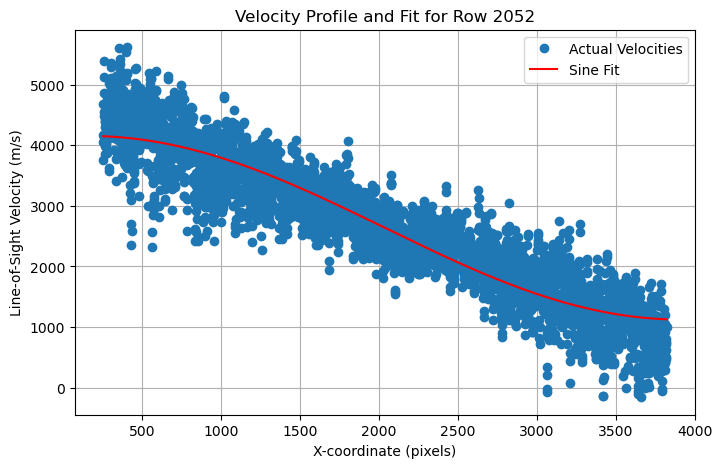

Row 1113: Fitted Rotation Velocity (Amplitude) = 1377.09 m/s


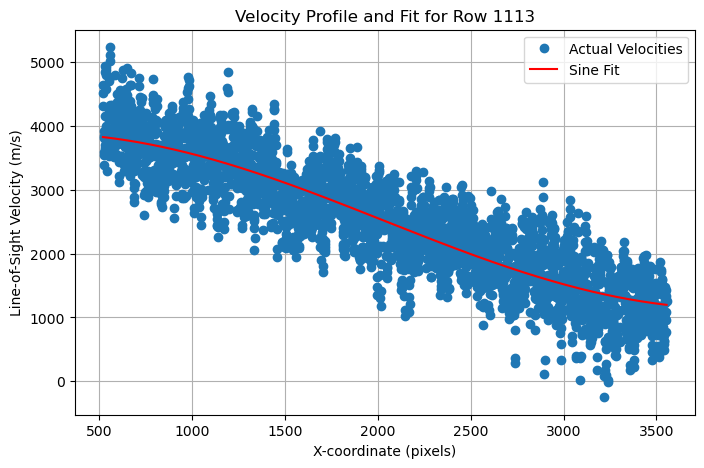

Row 2992: Fitted Rotation Velocity (Amplitude) = 1361.87 m/s


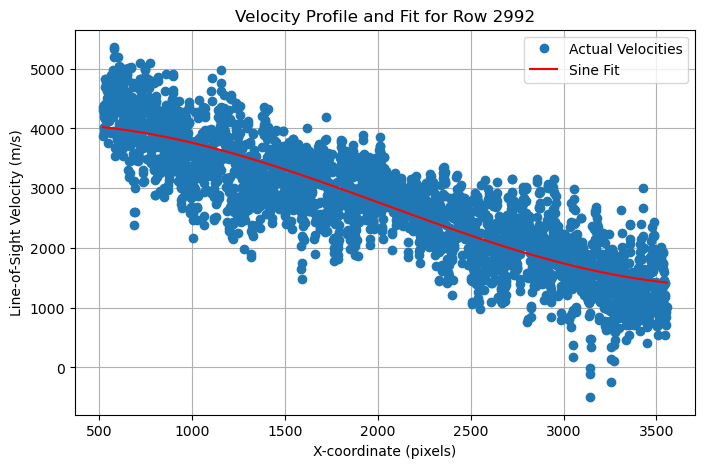

Row 549: Fitted Rotation Velocity (Amplitude) = 1041.14 m/s


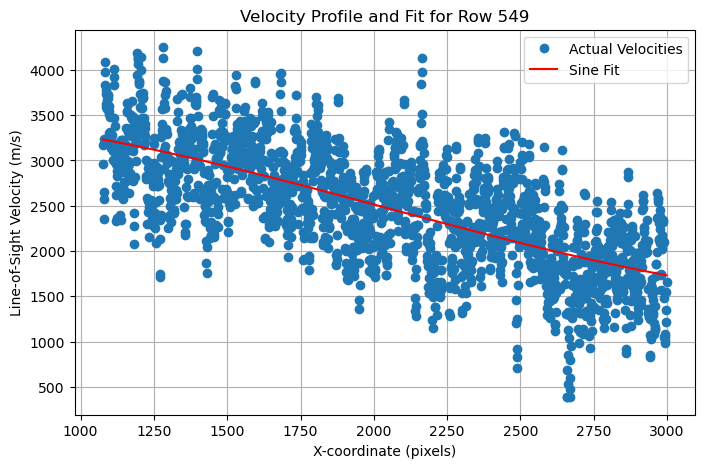

Row 3555: Fitted Rotation Velocity (Amplitude) = 1138.69 m/s


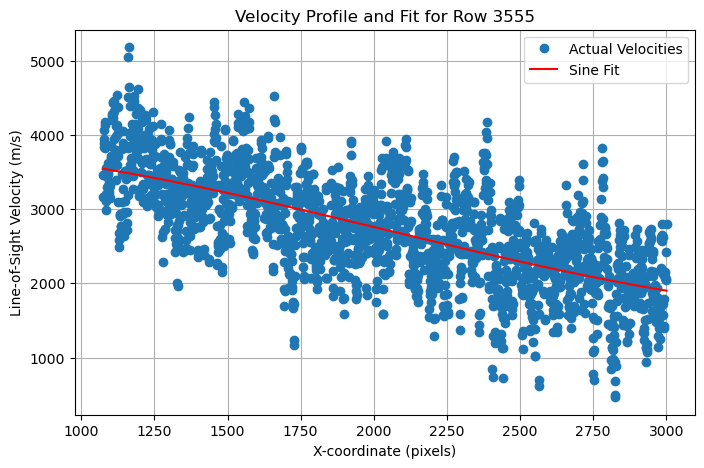

In [8]:
# Task 4.2: Fit a Sine Curve to Velocity Profiles (Conceptual)
# The line-of-sight velocity of a rotating sphere appears as a sine wave across its disk.
# v_los = V_rot * sin(theta), where theta is the angle from the central meridian.
# We'll simplify this: find the amplitude of the sine wave for each latitude.
# The amplitude corresponds to the rotational velocity at that latitude.

def sine_func(x, amplitude, offset):
    # A simple sine function for fitting
    # We expect velocity to go from negative to positive across the disk
    # We'll use a scaled x to represent angle across the disk
    # This is a very simplified model. A full model would include limb darkening, etc.
    # Here, x will be pixel coordinate. We need to map pixel x to an angle.
    # For simplicity, we just fit a sine curve to the raw pixel data and interpret amplitude.
    # X-coordinate from 0 to img_width will map to 0 to pi (or -pi/2 to pi/2)
    # We need to center the sine function on the x-coordinate of the Sun's center.
    phase = (x - center_x) / sun_radius * (np.pi/2) # Roughly map to -pi/2 to pi/2
    return amplitude * np.sin(phase) + offset

print("\nFitting sine curves to velocity profiles:")
latitude_rot_velocities = [] # Store (latitude_y_pixel, rotation_velocity_amplitude)

for row_idx, (x_coords, velocities) in velocity_profiles.items():
    if len(x_coords) > 10: # Ensure enough data points for fitting
        try:
            # Initial guess for amplitude (max_val - min_val / 2) and offset (mean)
            initial_amplitude = (np.max(velocities) - np.min(velocities)) / 2
            initial_offset = np.mean(velocities)
            ############
            ### SOLUTION:
            # write a 1-line command popt,pcov = (...) that uses curve_fit to fit the observed 
            # velocites and x-coords to a sine wave. Use keyword p0=[initial_amplitude, initial_offset]
            # 
            popt, pcov = curve_fit(sine_func, x_coords, velocities, p0=[initial_amplitude, initial_offset])
            amplitude_fit, offset_fit = popt

            print(f"Row {row_idx}: Fitted Rotation Velocity (Amplitude) = {abs(amplitude_fit):.2f} m/s")
            latitude_rot_velocities.append((row_idx, abs(amplitude_fit)))

            # Plot the fit
            plt.figure(figsize=(8, 5))
            plt.plot(x_coords, velocities, 'o', label='Actual Velocities')
            plt.plot(x_coords, sine_func(x_coords, *popt), 'r-', label='Sine Fit')
            plt.title(f"Velocity Profile and Fit for Row {row_idx}")
            plt.xlabel("X-coordinate (pixels)")
            plt.ylabel("Line-of-Sight Velocity (m/s)")
            plt.legend()
            plt.grid(True)
            plt.show()

        except RuntimeError:
            print(f"Could not fit curve for row {row_idx}. Not enough variation or data points.")
    else:
        print(f"Skipping fit for row {row_idx}: Not enough data points on disk.")


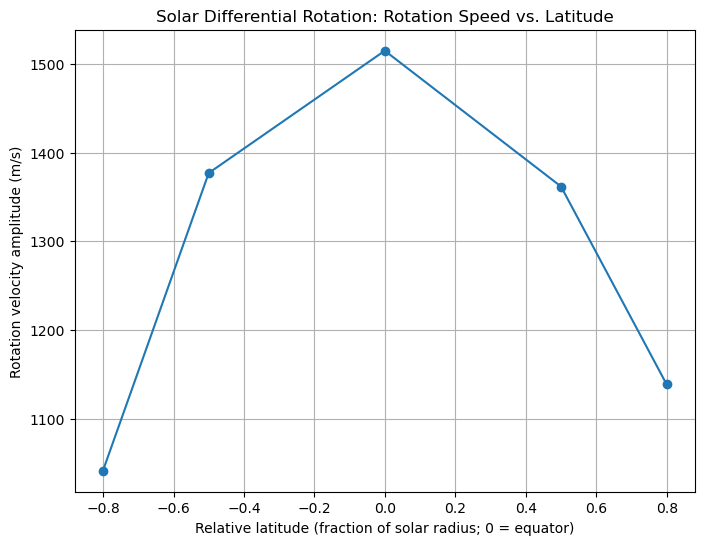


--- Section 5: Conclusion and Further Exploration ---
Congratulations! You've analyzed our Sun's visible features and investigated its differential rotation using Dopplergram data.
You've applied image processing, statistics, and even curve fitting using Python to learn something neat!


In [9]:
# Task 4.3: Plot Rotation Velocity vs. Latitude
# This is the key plot demonstrating differential rotation!
if len(latitude_rot_velocities) > 1:
    # Sort by latitude (row_idx) for clear plotting
    latitude_rot_velocities.sort(key=lambda x: x[0])
    latitudes = np.array([item[0] for item in latitude_rot_velocities])
    rot_velocities = np.array([item[1] for item in latitude_rot_velocities])

    # Convert pixel latitude to a more intuitive scale if possible (e.g., fractional radius)
    # 0 is equator, positive is North, negative is South
    relative_latitudes = (latitudes - center_y) / sun_radius

    plt.figure(figsize=(8, 6))
    
    #######
    #### SOLUTION
    # plot rot_velocities as a function of relative_latitudes
    plt.plot(relative_latitudes, rot_velocities, 'o-')
    plt.title("Solar Differential Rotation: Rotation Speed vs. Latitude")
    plt.xlabel("Relative latitude (fraction of solar radius; 0 = equator)")
    plt.ylabel("Rotation velocity amplitude (m/s)")
    plt.grid(True)
    plt.show()

    # Discussion Point:
    # - What does this plot tell you about the Sun's rotation?
    # - Which regions rotate fastest? Slowest?
    # - How does this differ from the rotation of a solid object like Earth?
    # - Why do you think the Sun exhibits differential rotation? 
    
# --- Section 5: Conclusion and Further Exploration ---

print("\n--- Section 5: Conclusion and Further Exploration ---")

print("Congratulations! You've analyzed our Sun's visible features and investigated its differential rotation using Dopplergram data.")
print("You've applied image processing, statistics, and even curve fitting using Python to learn something neat!")    


--- Section 5: Bonus Activity: Principal Component Analysis (PCA) for Image Compression ---
PCA is a powerful mathematical technique used to reduce the 'dimensionality' of data.
For images, it can help us find the most important patterns that capture most of the image's information,
which is useful for compression and noise reduction.


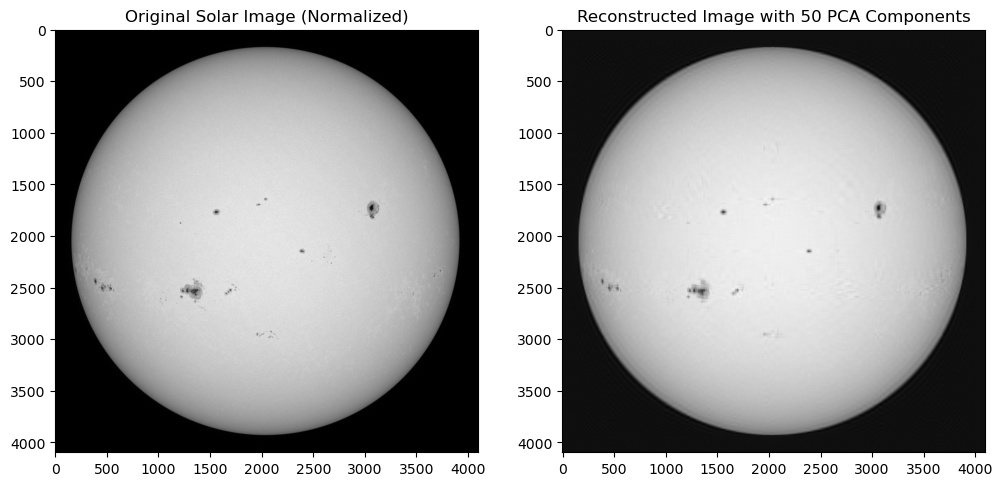

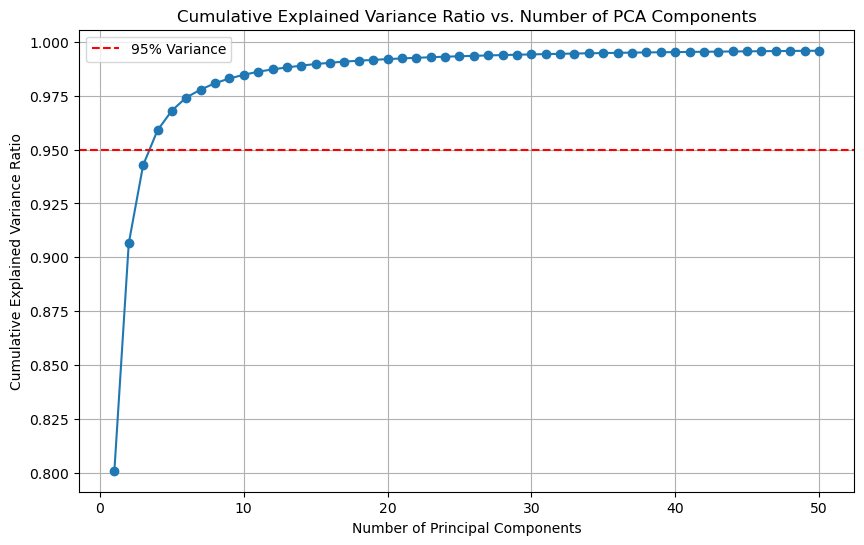

With 50 components, we explain 99.59% of the variance.


In [10]:
# Bonus: PCA

from sklearn.decomposition import PCA # Sci-kit Learn for PCA 

if visible_data is not None:
    print("\n--- Section 5: Bonus Activity: Principal Component Analysis (PCA) for Image Compression ---")
    print("PCA is a powerful mathematical technique used to reduce the 'dimensionality' of data.")
    print("For images, it can help us find the most important patterns that capture most of the image's information,")
    print("which is useful for compression and noise reduction.")

    # PCA works best on 2D data (rows as samples, columns as features).
    # An image is a 2D array. We'll treat each row as a 'sample' and each pixel in that row as a 'feature'.
    # Normalize the image data to be between 0 and 1, which is often good practice for PCA.
    normalized_visible_data = visible_data / 255.0

    # Task 5.1: Perform PCA on the image data
    # We will specify the number of components (n_components) to keep.
    # Each component represents a 'mode' or 'pattern' in the image data.

    # Try starting with a small number of components
    # The smaller the number, the more compression, but potentially less detail.
    n_components_pca = 50 # You can experiment with this number!

    # Your code here: Initialize PCA and fit it to the normalized image data.
    # The 'fit' step calculates the principal components.
    pca_solar = PCA(n_components=n_components_pca)
    pca_solar.fit(normalized_visible_data)

    # Now, transform the original data into the new PCA space (reduced dimensionality).
    reduced_solar_data = pca_solar.transform(normalized_visible_data)

    # And then, reconstruct the image using only these principal components.
    # This shows how much information is retained.
    reconstructed_solar_image = pca_solar.inverse_transform(reduced_solar_data)

    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(normalized_visible_data, cmap='gray')
    plt.title("Original Solar Image (Normalized)")

    plt.subplot(1, 2, 2)
    plt.imshow(reconstructed_solar_image, cmap='gray')
    plt.title(f"Reconstructed Image with {n_components_pca} PCA Components")
    plt.show()

    # Task 5.2: Analyze the Explained Variance Ratio
    # The 'explained_variance_ratio_' tells us how much of the original image's
    # variability (information) is captured by each principal component.
    # We can plot the cumulative sum to see how much total information we retain.

    explained_variance_ratio_solar = pca_solar.explained_variance_ratio_
    cumulative_variance_ratio_solar = np.cumsum(explained_variance_ratio_solar)

    plt.figure(figsize=(10, 6))
    plt.plot(range(1, len(cumulative_variance_ratio_solar) + 1), cumulative_variance_ratio_solar, marker='o', linestyle='-')
    plt.title("Cumulative Explained Variance Ratio vs. Number of PCA Components")
    plt.xlabel("Number of Principal Components")
    plt.ylabel("Cumulative Explained Variance Ratio")
    plt.grid(True)
    plt.axhline(y=0.95, color='r', linestyle='--', label='95% Variance')
    plt.legend()
    plt.show()

    print(f"With {n_components_pca} components, we explain {cumulative_variance_ratio_solar[-1]*100:.2f}% of the variance.")

    # Discussion Point:
    # 1. Look at the reconstructed image. How well does it resemble the original?
    # 2. Look at the cumulative explained variance plot. How many components would you need
    #    to capture, say, 90% or 95% of the information in the image?
    # 3. Why is PCA useful for tasks like image compression or noise reduction? (Hint: It focuses on essential patterns).
    # 4. How might PCA be used in actual solar physics research (e.g., classifying active regions, detecting subtle changes)?

